```
Classification
K-NN:-K Nearest Nieghbor
k always take odd so no tie in decision

CM=[[TN  FP]
    [FN  TP]]

Specifity(Numerator)=TN/(TN+FP)
Sensitivity(Denomerator)=TP/(FN+TP)
precision_score=TP/(TP+FP)
pros_label=1 ----> for positive
```

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [2]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
y=df['Outcome']
print(type(y))
x=df.drop(['Outcome'],axis=1)

<class 'pandas.core.series.Series'>


In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=1)
nn=KNeighborsClassifier(n_neighbors=5)
nn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [6]:
ypred=nn.predict(x_test)
ypred

array([1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [7]:
cm=confusion_matrix(y_test,ypred)
cm

array([[82, 17],
       [24, 31]])

In [8]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,TP,FN,FP)

82 31 24 17


In [9]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
precision_score=TP/(TP+FP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("Precision Score:",precision_score)

Specificity: 0.8282828282828283
Sensitivity: 0.5636363636363636
Precision Score: 0.6458333333333334


In [10]:
print("accuracy score:",accuracy_score(y_test,ypred))

accuracy score: 0.7337662337662337


In [11]:
accuracy=[]
for i in range(1,30):
    nn=KNeighborsClassifier(n_neighbors=i)
    nn.fit(x_train,y_train)
    ypred=nn.predict(x_test)
    accuracy.append(accuracy_score(y_test,ypred))

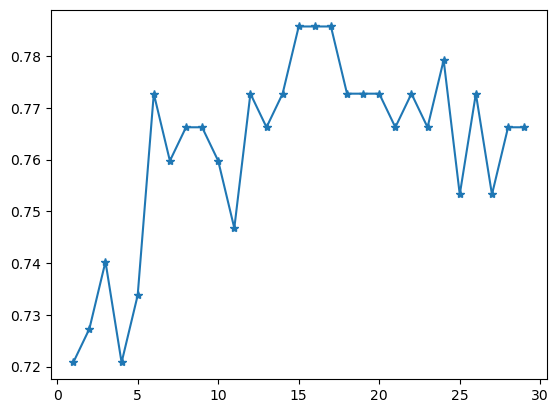

In [12]:
plt.plot(range(1,30),accuracy,marker='*')
plt.show()

In [13]:
print(accuracy)

[0.7207792207792207, 0.7272727272727273, 0.7402597402597403, 0.7207792207792207, 0.7337662337662337, 0.7727272727272727, 0.7597402597402597, 0.7662337662337663, 0.7662337662337663, 0.7597402597402597, 0.7467532467532467, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7857142857142857, 0.7857142857142857, 0.7857142857142857, 0.7727272727272727, 0.7727272727272727, 0.7727272727272727, 0.7662337662337663, 0.7727272727272727, 0.7662337662337663, 0.7792207792207793, 0.7532467532467533, 0.7727272727272727, 0.7532467532467533, 0.7662337662337663, 0.7662337662337663]


___

In [14]:
df=pd.read_csv("tshirt.csv")
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Height  18 non-null     int64 
 1   Wight   18 non-null     int64 
 2   Size    18 non-null     object
dtypes: int64(2), object(1)
memory usage: 564.0+ bytes


In [16]:
df.isna().sum()

Height    0
Wight     0
Size      0
dtype: int64

In [17]:
y=df['Size']
x=df.drop(['Size'],axis=1)

In [18]:
x

,Height,Wight
0,158,58
1,158,59
2,158,63
3,160,59
4,160,60
5,163,60
6,163,61
7,160,64
8,163,64
9,165,61


In [19]:
nn=KNeighborsClassifier(n_neighbors=5)
nn.fit(x,y)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
ypred=nn.predict(x)
ypred

array(['M', 'M', 'M', 'M', 'M', 'M', 'L', 'M', 'L', 'L', 'L', 'L', 'L',
       'L', 'L', 'L', 'L', 'L'], dtype=object)

In [21]:
cm=confusion_matrix(y,ypred)
cm

array([[10,  1],
       [ 1,  6]])

In [22]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [23]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)

Specificity: 0.9090909090909091
Sensitivity: 0.8571428571428571


In [24]:
print("accuracy score:",accuracy_score(y,ypred))

accuracy score: 0.8888888888888888


In [25]:
pre=TP/(TP+FP)
print("Precision Score:",pre)#in this it take by defalt 1=m in pos label
print("Precision Score(M):", metrics.precision_score(y,ypred,pos_label='M'))
print("Precision Score:(L)", metrics.precision_score(y,ypred,pos_label='L'))

Precision Score: 0.8571428571428571
Precision Score(M): 0.8571428571428571
Precision Score:(L) 0.9090909090909091


___

# Decision Tree

```
there are total three node
1) root
2) decision 
3) leaf
antropy formula
in this label data so first we have to convert num data
leaf node is last node and its accuracy is always 100
leaf node entropy is 0,0
if i'm use max_depth then its accuray is not 100


data ne category mathi numeric ma lavvu ---- feature transform
df['column_name']=np.where(condition,[x,y])


x-- root & decision node
y-- leaf node
```

In [26]:
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CGPA               18 non-null     int64
 1   Communication      18 non-null     int64
 2   Apptitude          18 non-null     int64
 3   Programming Skill  18 non-null     int64
 4   Job Offered        18 non-null     int64
dtypes: int64(5)
memory usage: 852.0 bytes


In [28]:
df.isna().sum()

CGPA                 0
Communication        0
Apptitude            0
Programming Skill    0
Job Offered          0
dtype: int64

In [29]:
x=df.drop("Job Offered",axis=1)
x

,CGPA,Communication,Apptitude,Programming Skill
0,2,1,1,1
1,1,1,1,1
2,0,0,0,1
3,0,1,0,0
4,2,1,1,0
5,2,1,1,1
6,1,0,0,0
7,1,0,0,1
8,2,0,1,1
9,1,1,1,1


In [30]:
y=df['Job Offered']
y

0     1
1     1
2     0
3     0
4     1
5     1
6     0
7     0
8     1
9     1
10    0
11    0
12    1
13    0
14    0
15    0
16    0
17    1
Name: Job Offered, dtype: int64

In [31]:
type(y)

pandas.core.series.Series

In [32]:
dt=DecisionTreeClassifier(criterion="entropy")
model=dt.fit(x,y)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
ypred=dt.predict(x)
ypred

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [34]:
diff=pd.DataFrame({"Actual":y,"Prediction":ypred})
diff

,Actual,Prediction
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [35]:
cm=confusion_matrix(y,ypred)
cm

array([[10,  0],
       [ 0,  8]])

In [36]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [37]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("accuracy score:",accuracy_score(y,ypred))
print("precision score:",metrics.precision_score(y,ypred))

Specificity: 1.0
Sensitivity: 1.0
accuracy score: 1.0
precision score: 1.0


In [38]:
plt.figure(figsize=(20,10))
plt.show()

<Figure size 2000x1000 with 0 Axes>

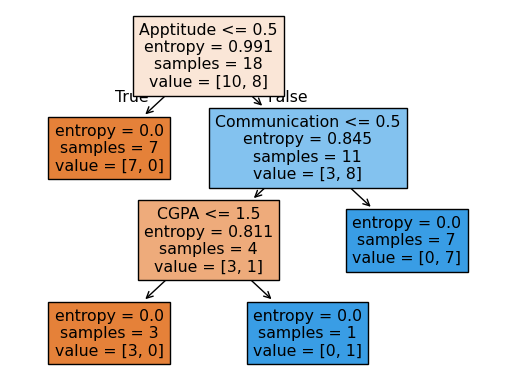

In [39]:
fea=x.columns
plot_tree(dt,feature_names=fea,filled=True)
plt.show()

___

In [40]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [41]:
x=df.drop('Outcome',axis=1)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [42]:
y=df['Outcome']
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [44]:
dt=DecisionTreeClassifier(criterion="entropy")
model=dt.fit(x_train,y_train)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
ypred=dt.predict(x_test)
ypred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1])

In [46]:
cm=confusion_matrix(y_test,ypred)
cm

array([[75, 24],
       [21, 34]])

In [47]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

75 24 21 34


In [48]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("accuracy score:",accuracy_score(y_test,ypred))
print("precision score:",metrics.precision_score(y_test,ypred))

Specificity: 0.7575757575757576
Sensitivity: 0.6181818181818182
accuracy score: 0.7077922077922078
precision score: 0.5862068965517241


# plt.figure(figsize=(20,10))
fea=x.columns
plot_tree(dt,feature_names=fea,filled=True,max_depth=3)
plt.show()

In [50]:
from sklearn import tree
calculation=tree.export_text(dt,feature_names=fea)
print(calculation)

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- BMI <= 9.10
|   |   |   |--- Pregnancies <= 7.50
|   |   |   |   |--- class: 0
|   |   |   |--- Pregnancies >  7.50
|   |   |   |   |--- class: 1
|   |   |--- BMI >  9.10
|   |   |   |--- DiabetesPedigreeFunction <= 0.67
|   |   |   |   |--- class: 0
|   |   |   |--- DiabetesPedigreeFunction >  0.67
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.71
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- DiabetesPedigreeFunction >  0.71
|   |   |   |   |   |--- class: 0
|   |--- BMI >  26.45
|   |   |--- Age <= 28.50
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- Pregnancies <= 7.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Pregnancies >  7.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- Age <= 22.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age >  22.50
|   |   |   |   |   |--- BMI <= 45.40
|   |   |   |   |   |   |--- BMI <= 38.35
|   |   |   |   |   |   |

___

# RANDOM FOREST

```
random forest means that basically works in multiple tree and after that it gives an a output of 

always random forest accuracy is more than a decision tree 
```

In [51]:
df=pd.read_csv("titanic_Random-Forest.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [53]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [54]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [55]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [56]:
df.drop(["PassengerId",'Name','Ticket','Cabin','Embarked'],axis=1,inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.000000,1,0,7.2500
1,1,1,female,38.000000,1,0,71.2833
2,1,3,female,26.000000,0,0,7.9250
3,1,1,female,35.000000,1,0,53.1000
4,0,3,male,35.000000,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000
887,1,1,female,19.000000,0,0,30.0000
888,0,3,female,29.699118,1,2,23.4500
889,1,1,male,26.000000,0,0,30.0000


In [57]:
y=df['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [58]:
x=df.drop("Survived",axis=1)
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.000000,1,0,7.2500
1,1,female,38.000000,1,0,71.2833
2,3,female,26.000000,0,0,7.9250
3,1,female,35.000000,1,0,53.1000
4,3,male,35.000000,0,0,8.0500
...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000
887,1,female,19.000000,0,0,30.0000
888,3,female,29.699118,1,2,23.4500
889,1,male,26.000000,0,0,30.0000


In [59]:
y.shape

(891,)

In [60]:
x.shape

(891, 6)

In [61]:
x['Sex']=np.where(x['Sex']=='male',1,0)
x

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.000000,1,0,7.2500
1,1,0,38.000000,1,0,71.2833
2,3,0,26.000000,0,0,7.9250
3,1,0,35.000000,1,0,53.1000
4,3,1,35.000000,0,0,8.0500
...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000
887,1,0,19.000000,0,0,30.0000
888,3,0,29.699118,1,2,23.4500
889,1,1,26.000000,0,0,30.0000


In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=1)
print(x.shape)

(891, 6)


In [63]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=1)

In [64]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
ypred=rf.predict(x_test)
ypred

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1])

In [66]:
diff=pd.DataFrame({"Actual":y_test,"Prediction":ypred})
diff

,Actual,Prediction
862,1,1
223,0,0
84,1,1
680,0,0
535,1,1
...,...,...
796,1,1
815,0,0
629,0,0
421,0,0


In [67]:
cm=confusion_matrix(y_test,ypred)
cm

array([[96, 10],
       [30, 43]])

In [68]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

96 10 30 43


In [69]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("accuracy score:",accuracy_score(y_test,ypred))
print("precision score:",metrics.precision_score(y_test,ypred))

Specificity: 0.9056603773584906
Sensitivity: 0.589041095890411
accuracy score: 0.776536312849162
precision score: 0.8113207547169812


___

In [70]:
df=pd.DataFrame({
    "weight":[150,170,140,180,160,185],
    "texture":['smooth','bumpy','smooth','bumpy','smooth','bumpy'],
    "color":['red','orange','green','orange','red','yellow'],
    "fruits":['apple','orange','apple','orange','apple','orange']
})
df

,weight,texture,color,fruits
0,150,smooth,red,apple
1,170,bumpy,orange,orange
2,140,smooth,green,apple
3,180,bumpy,orange,orange
4,160,smooth,red,apple
5,185,bumpy,yellow,orange


In [71]:
y=df['fruits']
y.shape

(6,)

In [72]:
x=df.drop('fruits',axis=1)
x.shape

(6, 3)

In [73]:
x['color']=np.where(x['color']=='red',0,(np.where(x['color']=='orange',1,(np.where(x['color']=='green',2,3)))))
x

,weight,texture,color
0,150,smooth,0
1,170,bumpy,1
2,140,smooth,2
3,180,bumpy,1
4,160,smooth,0
5,185,bumpy,3


In [74]:
x['texture']=np.where(x['texture']=='smooth',0,1)
x

,weight,texture,color
0,150,0,0
1,170,1,1
2,140,0,2
3,180,1,1
4,160,0,0
5,185,1,3


In [75]:
rf.fit(x,y)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
ypred=rf.predict(x)
ypred

array(['apple', 'orange', 'apple', 'orange', 'apple', 'orange'],
      dtype=object)

In [77]:
cm=confusion_matrix(y,ypred)
cm

array([[3, 0],
       [0, 3]])

In [78]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

3 0 0 3


In [79]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("accuracy score:",accuracy_score(y,ypred))
print("Precision Score:",TP/(TP+FP))

Specificity: 1.0
Sensitivity: 1.0
accuracy score: 1.0
Precision Score: 1.0


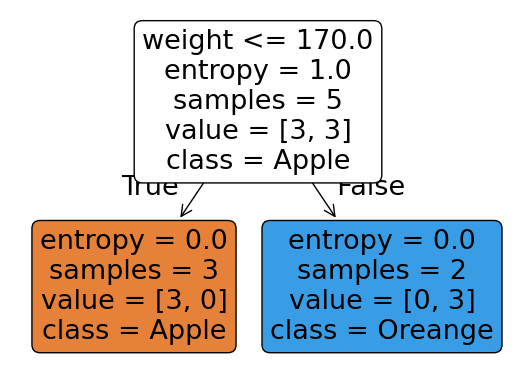

<Figure size 5000x3000 with 0 Axes>

In [80]:
choose_tree=rf.estimators_[39]
plot_tree(choose_tree,feature_names=['weight','textture','color'],filled=True,class_names=['Apple','Oreange'],rounded=True)
plt.figure(figsize=(50,30))
plt.show()

___

 # SVM-Support Vector Machine

```
SVC---Support Vector Classifier
means two classes data in marign distance is large so our accuracy increase
c>--> best accuracy
rbf=radial bases function
```

In [81]:
from sklearn.svm import SVC

In [82]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [83]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [84]:
y=df['Outcome']
y.shape

(768,)

In [85]:
x=df.drop(['Outcome'],axis=1)
x.shape

(768, 8)

In [88]:
sv=SVC(C=1,kernel='rbf',random_state=1)

In [89]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
sv.fit(x_train,y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [90]:
ypred=sv.predict(x_test)
ypred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [92]:
cm=confusion_matrix(y_test,ypred)
cm

array([[93,  6],
       [27, 28]])

In [93]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

93 6 27 28


In [96]:
Specificity=TN/(TN+FP)
Sensitivity=TP/(FN+TP)
print("Specificity:",Specificity)
print("Sensitivity:",Sensitivity)
print("accuracy score:",accuracy_score(y_test,ypred))
print("Precision Score:",metrics.precision_score(y_test,ypred))

Specificity: 0.9393939393939394
Sensitivity: 0.509090909090909
accuracy score: 0.7857142857142857
Precision Score: 0.8235294117647058


___